In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import joblib

c:\Users\deeks\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [55]:
df = pd.read_csv("../data/Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [56]:
df.shape

(200, 5)

In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [58]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [59]:
df.duplicated().sum()

np.int64(0)

In [60]:
df.drop("CustomerID", axis=1, inplace=True)

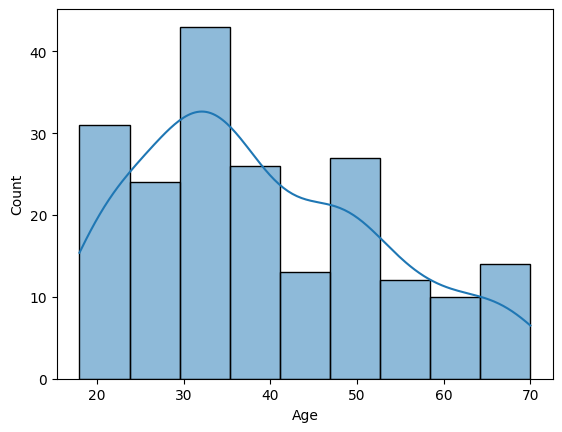

In [61]:
sns.histplot(df["Age"], kde=True)

plt.show()

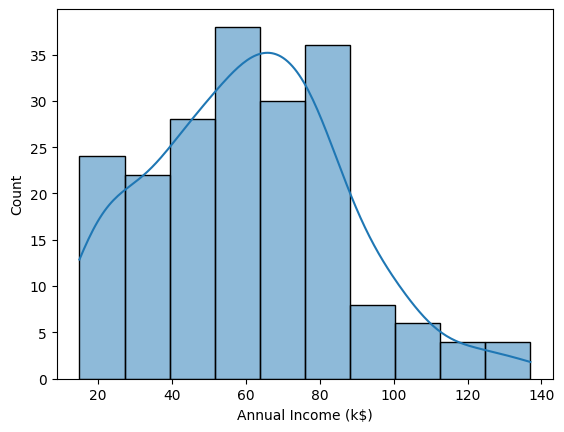

In [62]:
sns.histplot(df["Annual Income (k$)"], kde=True)

plt.show()

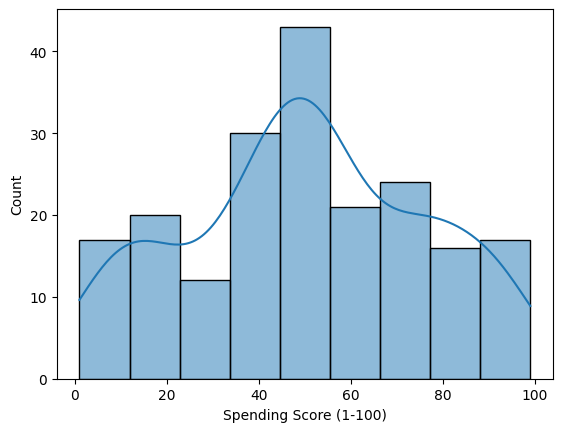

In [63]:
sns.histplot(df["Spending Score (1-100)"], kde=True)

plt.show()

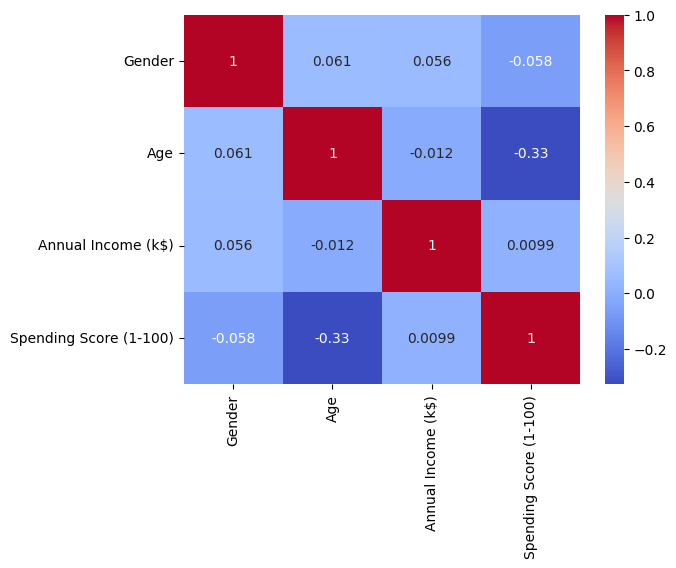

In [64]:
temp = df.copy()

temp["Gender"] = LabelEncoder().fit_transform(temp["Gender"])

sns.heatmap(
    temp.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [65]:
le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])

In [66]:
X = df[
    ['Annual Income (k$)',
     'Spending Score (1-100)']
]

In [67]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [68]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=50,
        max_iter=1000,
        random_state=42
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

print(wcss)

[400.0, 269.6910121927639, 157.70400815035947, 108.92131661364355, 65.56840815571681, 55.057348270385994, 44.86475569922557, 37.14811697229111, 32.36022982569204, 29.07617685124427]


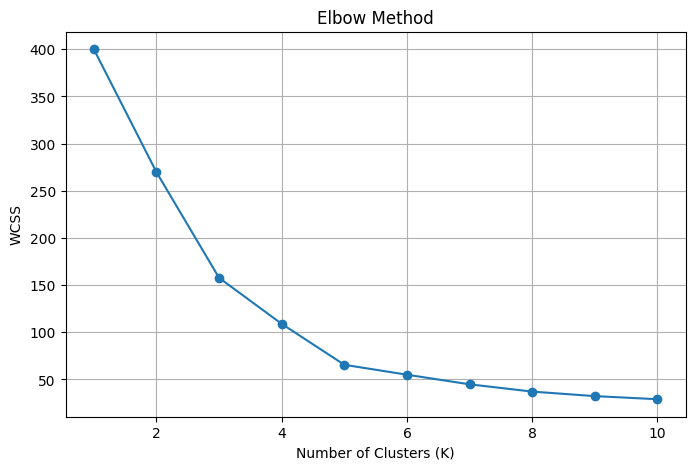

In [69]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

In [70]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=50,
        max_iter=1000,
        random_state=42
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    sil_scores.append(score)

    print(f"K={k} -> {score:.4f}")

K=2 -> 0.3213
K=3 -> 0.4666
K=4 -> 0.4939
K=5 -> 0.5547
K=6 -> 0.5399
K=7 -> 0.5281
K=8 -> 0.4567
K=9 -> 0.4565
K=10 -> 0.4494


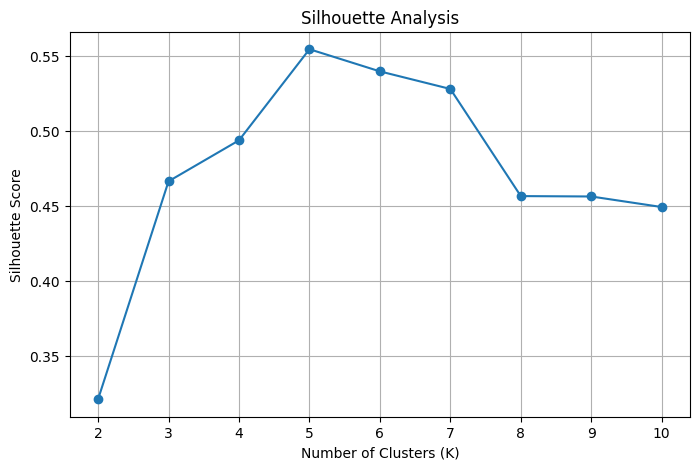

In [71]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    sil_scores,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.grid(True)

plt.show()

In [72]:
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    n_init=50,
    max_iter=1000,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

In [73]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

sil_score = silhouette_score(X_scaled, clusters)
db_score = davies_bouldin_score(X_scaled, clusters)

print("Silhouette Score:", sil_score)
print("Davies Bouldin Score:", db_score)
print("Inertia:", kmeans.inertia_)

Silhouette Score: 0.5546571631111091
Davies Bouldin Score: 0.5722356162263352
Inertia: 65.56840815571681


In [74]:
df["Cluster"] = clusters

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,19,15,39,4
1,1,21,15,81,2
2,0,20,16,6,4
3,0,23,16,77,2
4,0,31,17,40,4


In [80]:
joblib.dump(
    df,
    "models/kmeans_df.pkl"
)

['models/kmeans_df.pkl']

In [75]:
df.groupby("Cluster")[[
    "Annual Income (k$)",
    "Spending Score (1-100)"
]].mean()

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [76]:
centroids = scaler.inverse_transform(
    kmeans.cluster_centers_
)

centroids_df = pd.DataFrame(
    centroids,
    columns=X.columns
)

centroids_df

,Annual Income (k$),Spending Score (1-100)
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


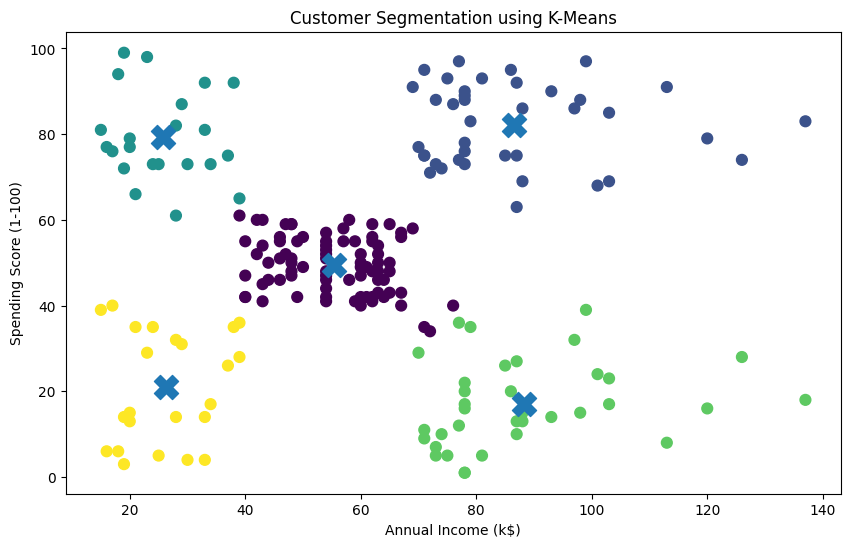

In [77]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    s=60
)

centroids = scaler.inverse_transform(
    kmeans.cluster_centers_
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    marker='X',
    s=300
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using K-Means")

plt.show()

In [78]:

joblib.dump(
    scaler,
    "models/scaler.pkl"
)

['models/scaler.pkl']

In [79]:
joblib.dump(
    kmeans,
    "models/kmeans_model.pkl"
)


['models/kmeans_model.pkl']